In [1]:
import os
import time
import string

import numpy as np
import pandas as pd

from datetime import datetime, timedelta
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

from tqdm import tqdm

# Font
from matplotlib import font_manager
font_path = "/workspace/KENTECH/fonts/"
font_list = os.listdir(font_path)
for font_file in font_list:
    try:
        font_manager.fontManager.addfont(font_path + font_file)
    except:
        raise Exception(f"Cannot Load {font_path+font_file}")

plt.rcParams["figure.dpi"] = 300

In [26]:
import sys
sys.path.append( '/workspace/KISTI_DB_Manager/' )

from KISTI_DB_Manager import manage, preview, processing, plot, __init__

import importlib as imp
, imp.reload(__init__), imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

In [20]:
json_ex = {'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:000203024800008',
 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
    'edition': {'@value': 'WOS.SSCI'}},
   'pub_info': {'@sortdate': '1945-07-01',
    '@pubyear': '1945',
    '@has_abstract': 'N',
    '@coverdate': 'JUL 1945',
    '@pubmonth': 'JUL',
    '@vol': '8',
    '@issue': '3',
    '@pubtype': 'Journal',
    'page': {'@begin': '212',
     '@end': '213',
     '@page_count': '2',
     '#text': '212-213'}},
   'titles': {'@count': '6',
    'title': [{'@type': 'source', '#text': 'AMERICAN ARCHIVIST'},
     {'@type': 'source_abbrev', '#text': 'AM ARCHIVIST'},
     {'@type': 'abbrev_iso', '#text': 'Am. Arch.'},
     {'@type': 'abbrev_11', '#text': 'AM ARCHIVIS'},
     {'@type': 'abbrev_29', '#text': 'AMER ARCH'},
     {'@type': 'item',
      '#text': 'Thirteenth annual report on historical collections, University of Virginia Library, for the year 1942-43'}]},
   'names': {'@count': '1',
    'name': {'@seq_no': '1',
     '@role': 'author',
     '@r_id': 'ELG-3487-2022',
     '@claim_status': 'false',
     'display_name': 'Alldredge, Everett O.',
     'full_name': 'Alldredge, Everett O.',
     'wos_standard': 'Alldredge, EO',
     'first_name': 'Everett O.',
     'last_name': 'Alldredge'}},
   'doctypes': {'@count': '1', 'doctype': 'Book Review'},
   'publishers': {'publisher': {'address_spec': {'@addr_no': '1',
      'full_address': '527 S WELLS ST, 5TH FLOOR, CHICAGO, IL 60607 USA',
      'city': 'CHICAGO'},
     'names': {'@count': '1',
      'name': {'@role': 'publisher',
       '@seq_no': '1',
       '@addr_no': '1',
       'display_name': 'SOC AMER ARCHIVISTS',
       'full_name': 'SOC AMER ARCHIVISTS',
       'unified_name': 'Soc Amer Archivists'}}}}},
  'fullrecord_metadata': {'languages': {'@count': '1',
    'language': {'@type': 'primary', '#text': 'English'}},
   'normalized_languages': {'@count': '1',
    'language': {'@type': 'primary', '#text': 'English'}},
   'normalized_doctypes': {'@count': '1', 'doctype': 'Review'},
   'references': {'@count': '1',
    'reference': {'@occurenceOrder': '1',
     'uid': 'WOS:000203024800008.1',
     'year': '1943',
     'citedWork': '13 ANN REPORT HIST C'}},
   'addresses': {'@count': '0'},
   'category_info': {'headings': {'@count': '1',
     'heading': 'Science & Technology'},
    'subheadings': {'@count': '1', 'subheading': 'Technology'},
    'subjects': {'@count': '2',
     'subject': [{'@ascatype': 'traditional',
       '#text': 'Information Science & Library Science'},
      {'@ascatype': 'extended',
       '#text': 'Information Science & Library Science'}]}},
   'fund_ack': None},
  'item': {'@xmlns:xsi': 'http://www.w3.org/2001/XMLSchema-instance',
   '@xsi:type': 'itemType_wos',
   'ids': {'@avail': 'Y', '#text': 'V44TK'},
   'bib_id': '8 (3): 212-213 JUL 1945',
   'bib_pagecount': {'@type': 'Journal', '#text': '62'},
   'reviewed_work': {'languages': {'@count': '1', 'language': 'English'},
    'rw_year': '1943'}}},
 'dynamic_data': {'cluster_related': {'identifiers': {'identifier': [{'@type': 'accession_no',
      '@value': 'V44TK'},
     {'@type': 'issn', '@value': '0360-9081'}]}}}}

json_data = {
    "parent1": {
        "child1": ["listValue1", "listValue2"],
        "child2": {
            "grandchild1": "value1",
            "grandchild2": "value2",
        },
        "child3": [
            {"grandchild3": {"GGC1":"v1", "GGC2":"v2", "GGC3":["v3", "v3"]}},
            {"grandchild3": {"GGC1":"v1", "GGC2":"v2", "GGC3":["v3", "v3", "v3"]}},
            {"grandchild3": {"GGC1":"v1", "GGC2":"v2", "GGC3":["v3"]}},
        ],
    },
    "parent2": "value3",
}

In [75]:
def init_vis_structure(json_dict, G, origin, count_dict, xy_unit=(14,1), sep='__', except_keys=except_keys):
    """
    Initializes the visualization structure for a given JSON dictionary by mapping it 
    onto a graph G, using positional information based on the hierarchical depth 
    and the number of sub-items.

    Parameters:
    - json_dict (dict): JSON dictionary to visualize.
    - G (networkx.DiGraph): A directed graph object from NetworkX where nodes and edges will be added.
    - origin (str): The root node's identifier in the graph.
    - count_dict (dict): A dictionary mapping node types to their counts for position calculation.
    - xy_unit (tuple): A tuple representing the unit distance in x (width) and y (height) directions between nodes (default is (14, 1)).
    - sep (str): Separator used to distinguish levels in the hierarchical structure (default is '__').

    Returns:
    - tuple: Returns a tuple containing the updated graph G, positions dictionary, labels dictionary, and types Series.
    """
    from KISTI_DB_Manager.processing import json_to_key_pairs
    from KISTI_DB_Manager.plot import get_position_grid

    key_pairs = json_to_key_pairs(json_dict, parent=origin, parent_type='Dict')
    types = key_pairs.set_index('branch')['type']
    
    df_pos = get_position_grid(types, origin, count_dict)
    msk = df_pos['type'].str.contains('List')
    df_pos.loc[msk, 'cnt'] = 1
    msk = df_pos['type'].str.contains('Dict')
    df_pos.loc[msk, 'cnt'] = 0
    msk = df_pos['type'].str.contains('Value in')
    df_pos.loc[msk, 'cnt'] = 1
    df_pos['x'] = df_pos['depth']*xy_unit[0]
    df_pos['y'] = df_pos[::-1].cumsum()['cnt']*xy_unit[1]
    df_pos['name'] = [sep.join([_x for _x in x if _x != '']) for x in df_pos.index.values]
    return df_pos
    edges = key_pairs[['parent', 'branch']].dropna().values
    G.add_edges_from(edges)
    pos = {n:(x, y) for n, x, y in df_pos[['name', 'x', 'y']].values}
    labels = {x:x.split('__')[-1] for x in list(G.nodes())}
    return G, pos, labels, types

init_vis_structure(json_ex, G, origin, count_dict, except_keys=except_keys)

type  \
rank_1 rank_2           rank_3          rank_4 rank_5 rank_6 rank_7 rank_8                          
WoS                                                                                          Dict   
       @r_id_disclaimer                                                                     Value   
       UID                                                                                  Value   
       dynamic_data                                                                          Dict   
                        cluster_related                                                      Dict   
...                                                                                           ...   
       static_data      summary         titles                                               Dict   
                                               @count                                       Value   
                                               title                                 List of Dict   
                                                      #text                 Value in List of Dict   
                                                      @type                 Value in List of Dict   

                                                                            depth  \
rank_1 rank_2           rank_3          rank_4 rank_5 rank_6 rank_7 rank_8          
WoS                                                                             1   
       @r_id_disclaimer                                                         2   
       UID                                                                      2   
       dynamic_data                                                             2   
                        cluster_related                                         3   
...                                                                           ...   
       static_data      summary         titles                                  4   
                                               @count                           5   
                                               title                            5   
                                                      #text                     6   
                                                      @type                     6   

                                                                            cnt  \
rank_1 rank_2           rank_3          rank_4 rank_5 rank_6 rank_7 rank_8        
WoS                                                                           0   
       @r_id_disclaimer                                                       1   
       UID                                                                    1   
       dynamic_data                                                           0   
                        cluster_related                                       0   
...                                                                         ...   
       static_data      summary         titles                                0   
                                               @count                         1   
                                               title                          0   
                                                      #text                   1   
                                                      @type                   1   

                                                                             x  \
rank_1 rank_2           rank_3          rank_4 rank_5 rank_6 rank_7 rank_8       
WoS                                                                         14   
       @r_id_disclaimer                                                     28   
       UID                                                                  28   
       dynamic_data                                                         28   
                        cluster_related                                     42   
...                

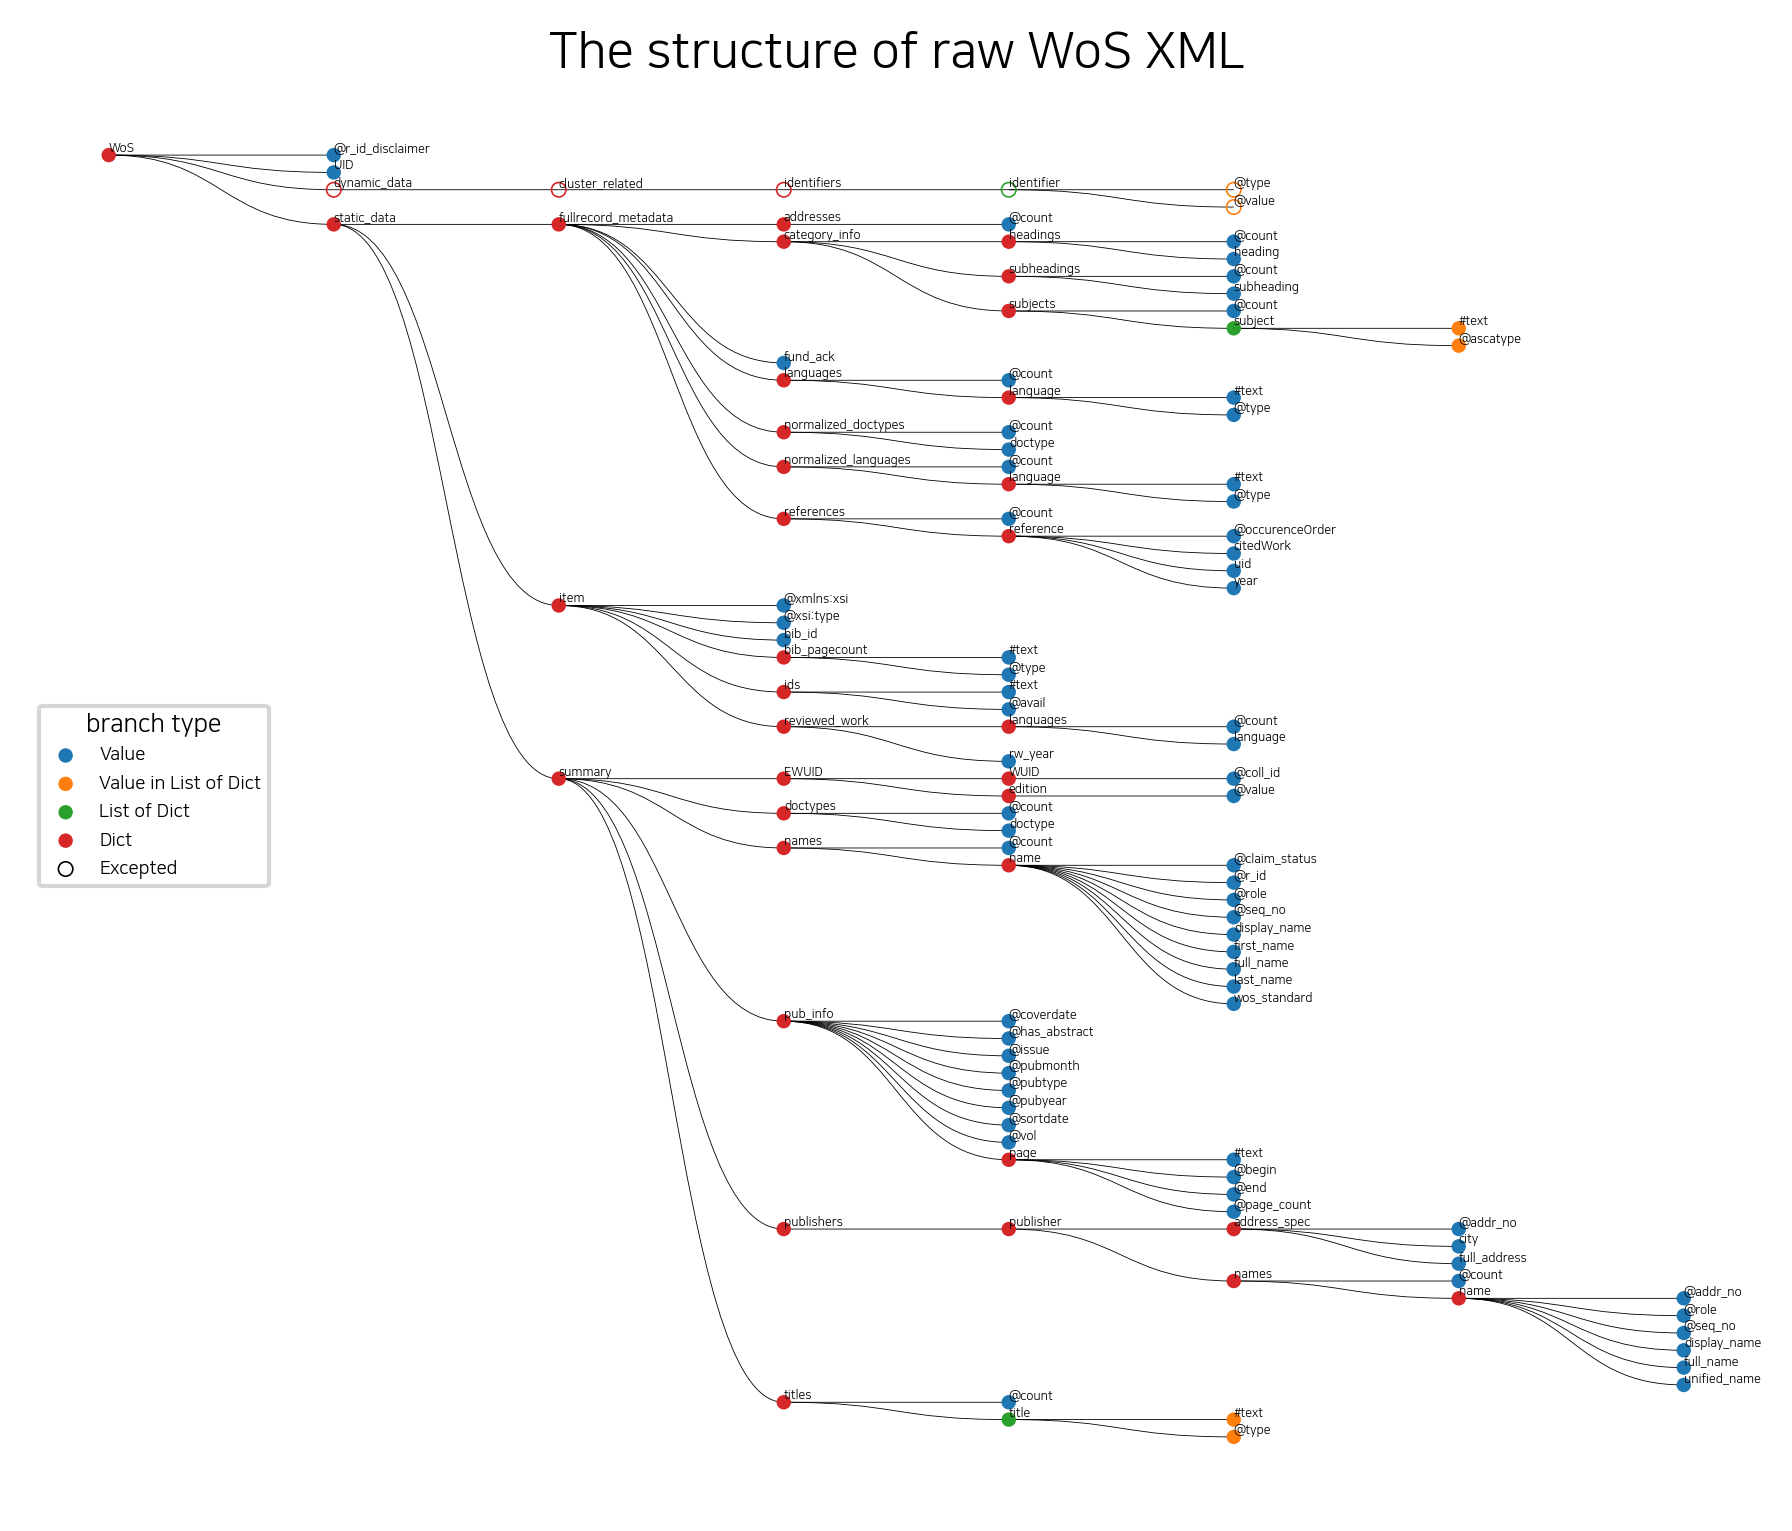

In [142]:
import networkx as nx

node_size = 12
font_size = 3
count_dict = {
        'Value':1, 'Value in List of Dict':1, 'List of Dict':0, 'Dict':0, 'List of Value':1
    }
except_keys = ['dynamic_data']
sep = '__'
origin = 'WoS'
title = 'The structure of raw WoS XML'
G = nx.Graph()
G, pos, labels, types = plot.init_vis_structure(json_ex, G, origin, count_dict, except_keys=except_keys)
# G, pos, labels, types = init_vis_structure(json_ex, G, origin, count_dict, except_keys=except_keys)

N_ROW = 1
N_COL = 2
X_SIZE = 6
Y_SIZE = 5
DPI = 300
plt.rcParams['font.family'] = ['NanumSquare', 'Helvetica']
# plt.rcParams['font.family'] = ['Helvetica', 'NanumSquare']

fig=plt.figure(figsize = (X_SIZE*N_COL,Y_SIZE*N_ROW), dpi=DPI)
spec = gridspec.GridSpec(ncols=N_COL, nrows=N_ROW, figure=fig, )#, width_ratios=[1,1,.1], wspace=.3)
axes = []
axi=0
ax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col

# Draw Edge with Bezier
plot.draw_Bezier_edges(
    G, pos, origin, ax, w=.2,
    ratio=0.5, color='black', weight=False, method='horizontal')


for i, key in enumerate(count_dict.keys()):
    nodelist = types[types == key].index
    if len(nodelist)> 0:
        msk = np.array([np.isin(except_keys, nl.split(sep)).any() for nl in nodelist])
        nodelist_excepted = nodelist[msk]
        collection_excepted = nx.draw_networkx_nodes(G, pos, nodelist=nodelist_excepted, node_size=node_size, label="__none",
                                            node_color='none', alpha=1., ax=ax, edgecolors=f'C{i}',)
        collection_excepted.set_zorder(2.1)
        collection_excepted.set_linewidth(.4)
        # collection.remove()
        nodelist_regularized = nodelist[~msk]
        collection_regularized = nx.draw_networkx_nodes(G, pos, nodelist=nodelist_regularized, node_size=node_size, label=key,
                                            node_color=f'C{i}', alpha=1., ax=ax, edgecolors='none')
        collection_regularized.set_zorder(2.1) # patch: 1, line: 2, text: 3
_ecpt = ax.scatter([],[], s=node_size, label="Excepted", c='none', alpha=1., edgecolors=f'black',)
_ecpt.set_zorder(2.1)
_ecpt.set_linewidth(.4)
_labels = nx.draw_networkx_labels(G, pos, labels=labels, 
                                  horizontalalignment='left', verticalalignment='bottom', 
                                  font_family='NanumSquare', 
                                  font_size=font_size, ax=ax)

legend = plt.legend(scatterpoints=1, fontsize=font_size*1.5, loc='center left', title='branch type', title_fontsize=font_size*2.)
for item in legend.legend_handles:
    item._sizes = [node_size]
# plt.margins(x=.1)
# plt.subplots_adjust(right=1.)
plt.tight_layout()
plt.axis('off')
plt.title(title)
plt.show()

In [102]:
types[types == key].index

Index([], dtype='object', name='branch')

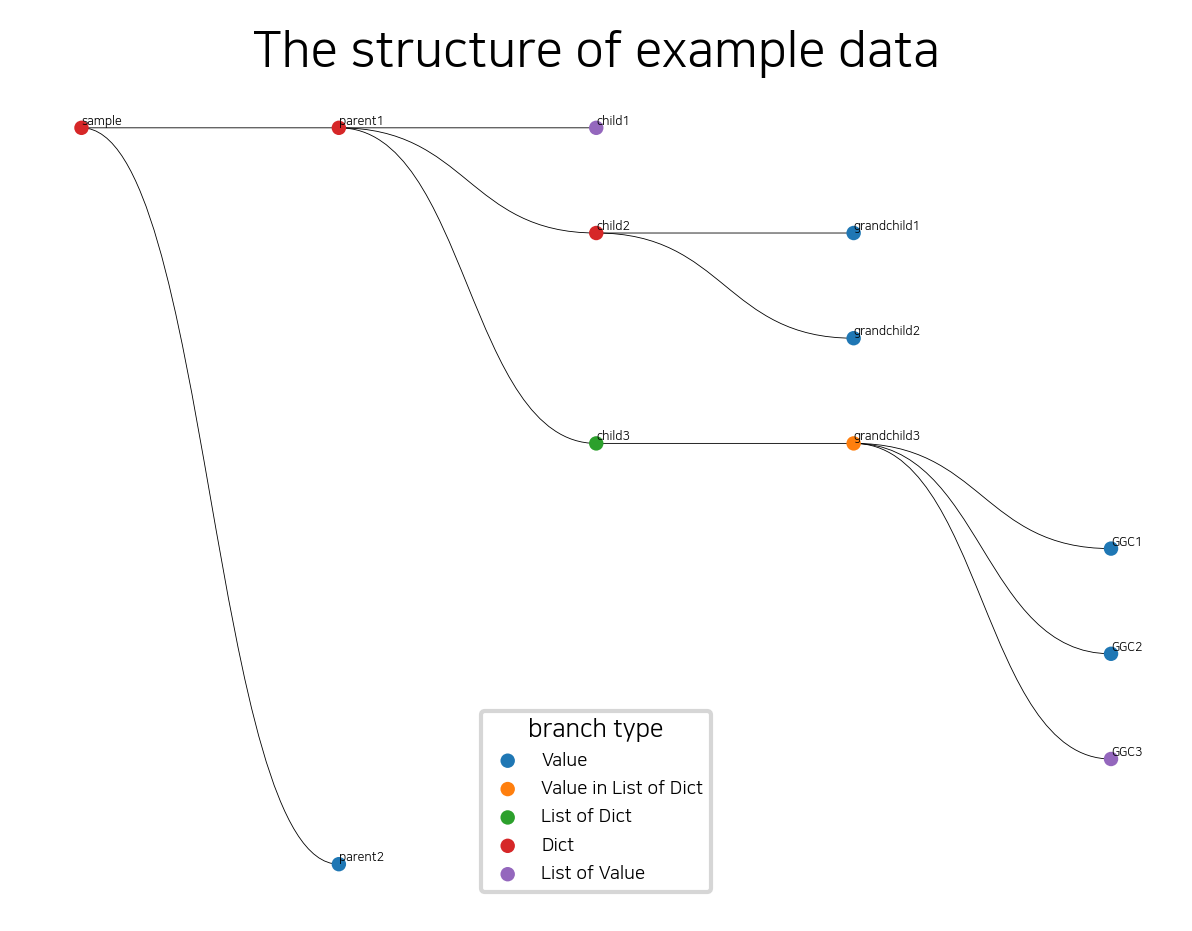

In [63]:
import networkx as nx

node_size = 12
font_size = 3
count_dict = {
        'Value':1, 'Value in List of Dict':1, 'List of Dict':0, 'Dict':0, 'List of Value':0
    }
origin = 'sample'
title = 'The structure of example data'
G = nx.Graph()
G, pos, labels, types = plot.init_vis_structure(json_data, G, origin, count_dict)

N_ROW = 1
N_COL = 2
X_SIZE = 4
Y_SIZE = 3
DPI = 300
plt.rcParams['font.family'] = ['NanumSquare', 'Helvetica']
# plt.rcParams['font.family'] = ['Helvetica', 'NanumSquare']

fig=plt.figure(figsize = (X_SIZE*N_COL,Y_SIZE*N_ROW), dpi=DPI)
spec = gridspec.GridSpec(ncols=N_COL, nrows=N_ROW, figure=fig, )#, width_ratios=[1,1,.1], wspace=.3)
axes = []
axi=0
ax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col

# Draw Edge with Bezier
plot.draw_Bezier_edges(
    G, pos, origin, ax, w=.2,
    ratio=0.5, color='black', weight=False, method='horizontal')

for i, key in enumerate(count_dict.keys()):
    nodelist = types[types == key].index
    collection = nx.draw_networkx_nodes(G, pos, nodelist=nodelist, node_size=node_size, label=key,
                                        node_color=f'C{i}', alpha=1., ax=ax, edgecolors='none')
    collection.set_zorder(2.1) # patch: 1, line: 2, text: 3

_labels = nx.draw_networkx_labels(G, pos, labels=labels, 
                                  horizontalalignment='left', verticalalignment='bottom', 
                                  font_family='NanumSquare', 
                                  font_size=font_size, ax=ax)

legend = plt.legend(scatterpoints=1, fontsize=font_size*1.5, loc='lower center', title='branch type', title_fontsize=font_size*2.)
for item in legend.legend_handles:
    item._sizes = [node_size]
# plt.margins(x=.1)
# plt.subplots_adjust(right=1.)
plt.tight_layout()
plt.axis('off')
plt.title(title)
plt.show()

In [93]:
import sys
sys.path.append( '/workspace/KISTI_DB_Manager/' )

from KISTI_DB_Manager import manage, preview, processing, plot

import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

In [21]:
import KISTI_DB_Manager